In [ ]:
!pip install groq -q

print("Libraries installed successfullty")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.7 MB/s eta 0:00:00
Libraries installed successfullty


In [ ]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re
print("all Libraries imported successfully")

all Libraries imported successfully


In [ ]:
import os
os.environ["GROQ_API_KEY"] = "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"
client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "llama-3.1-8b-instant"
print("Groq client installed successfully")
print(f"Using model: {MODEL}")

Groq client installed successfully
Using model: llama-3.1-8b-instant


In [ ]:
import io
df = pd.read_csv('/content/student_performance.csv')
display(df.head())


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
conn = sqlite3.connect("college.db")

df.to_sql("students", conn, if_exists="replace",index=False)

print("Database created: college_db")
print("Table 'studnets' created with 30 student records")

Test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)

print(f"\nVerification: {Test_df['total_rows'][0]} rows in database")

Database created: college_db
Table 'studnets' created with 30 student records

Verification: 30 rows in database


In [ ]:
cursor = conn.cursor()
table_name = "students"
cursor.execute(f"PRAGMA table_info({table_name})")

columns = cursor.fetchall()

In [ ]:
def get_schema(conn, table_name="students"):
    cursor = conn.cursor()

    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()

    schema_lines = [f"Table: {table_name}"]
    schema_lines.append("Columns:")

    for col in columns:
        schema_lines.append(f"  -{col[1]} ({col[2]})")

    cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
    sample_rows = cursor.fetchall()
    schema_lines.append("\nSample rows (first 3):")

    for row in sample_rows:
        schema_lines.append(f"  {row}")

    return "\n".join(schema_lines)
schema = get_schema(conn)
print(schema)

Table: students
Columns:
  -student_id (INTEGER)
  -name (TEXT)
  -age (INTEGER)
  -gender (TEXT)
  -department (TEXT)
  -semester (INTEGER)
  -math_score (INTEGER)
  -science_score (INTEGER)
  -english_score (INTEGER)
  -programming_score (INTEGER)
  -attendance_percentage (INTEGER)
  -city (TEXT)
  -admission_year (INTEGER)

Sample rows (first 3):
  (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [ ]:
def generate_sql(user_question, schema_text, client, model):
  """
  Sends the user's question and database schema to the LLM to generate an SQL query.
  """

  system_prompt = f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following structure:
  {schema_text}


  RULES YOU MUST FOLLOW :
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """
  response =  client.chat.completions.create(
  model = model,
  messages =[
  {
      "role": "system", "content": system_prompt
  },
  {
      "role": "user", "content": user_question
  }
  ],
  temperature =0.0
  )
  sql_query = response.choices[0].message.content.strip()
  return sql_query

question = "show me all female students"

print(f" question :{question}")
print("\nGenerating SQL....")

MODEL = "llama-3.1-8b-instant" # Corrected model name
sql = generate_sql(question, schema, client, MODEL)
print(f"\nGenerated SQL : {sql}")

 question :show me all female students

Generating SQL....

Generated SQL : SELECT * FROM students WHERE gender = 'Female'


In [ ]:
def execute_sql(sql_query, conn):
    clean_sql = sql_query.strip()
    # Fixed SyntaxError: removed extra single quotes
    clean_sql = re.sub(r'sql\s*', '', clean_sql)
    # Fixed typo: removed space between clean and _sql
    clean_sql = clean_sql.strip()
    try:
        result_df = pd.read_sql_query(clean_sql, conn)
        # Fixed 'none' to 'None'
        return result_df, None
    except Exception as e:
        return None, str(e)

# These lines were incorrectly indented within the function definition
# and are now placed outside to call the function after it's defined.
print(f"Executing SQL: {sql}")
result, error = execute_sql(sql, conn)

if error:
    print(f"Error: {error}")
else:
    print(f"\nQuery returned {len(result)} rows:")
    print(result)

Executing SQL: SELECT * FROM students WHERE gender = 'Female'

Query returned 15 rows:
    student_id            name  age  gender        department  semester  \
0         1002     Priya Patel   20  Female  Computer Science         2   
1         1004     Sneha Reddy   20  Female        Mechanical         2   
2         1006     Meera Joshi   20  Female       Electronics         2   
3         1008     Divya Singh   19  Female  Computer Science         2   
4         1010      Ananya Das   19  Female  Computer Science         2   
5         1012     Pooja Gupta   19  Female             Civil         2   
6         1014   Kavya Nambiar   20  Female        Mechanical         2   
7         1016    Ritu Agarwal   20  Female       Electronics         2   
8         1018  Swati Kulkarni   19  Female  Computer Science         2   
9         1020    Nisha Kapoor   19  Female  Computer Science         2   
10        1022     Tanvi Mehta   19  Female  Computer Science         2   
11        102

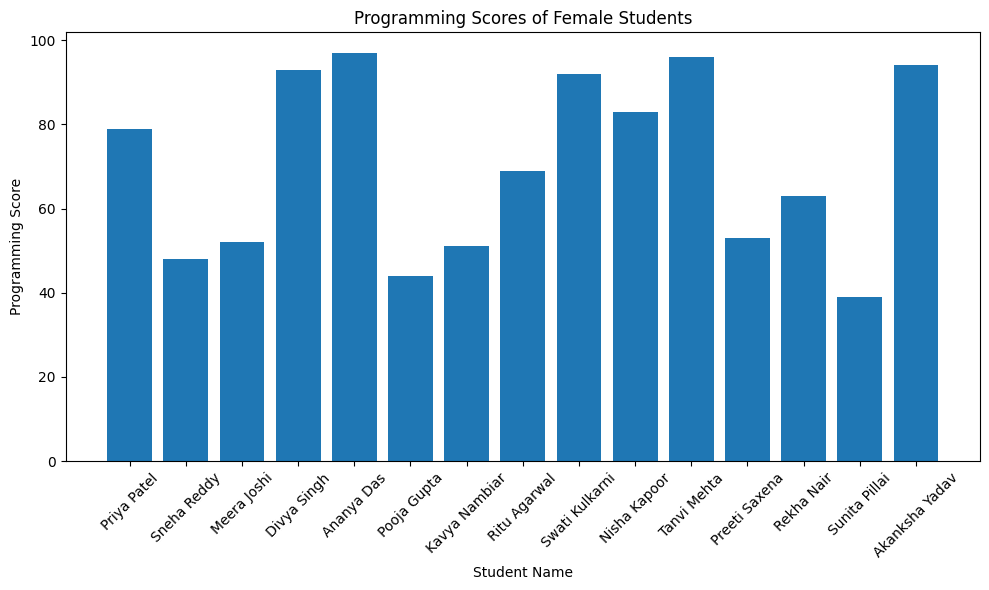

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(result['name'], result['programming_score'])

plt.title('Programming Scores of Female Students')
plt.xlabel('Student Name')
plt.ylabel('Programming Score')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

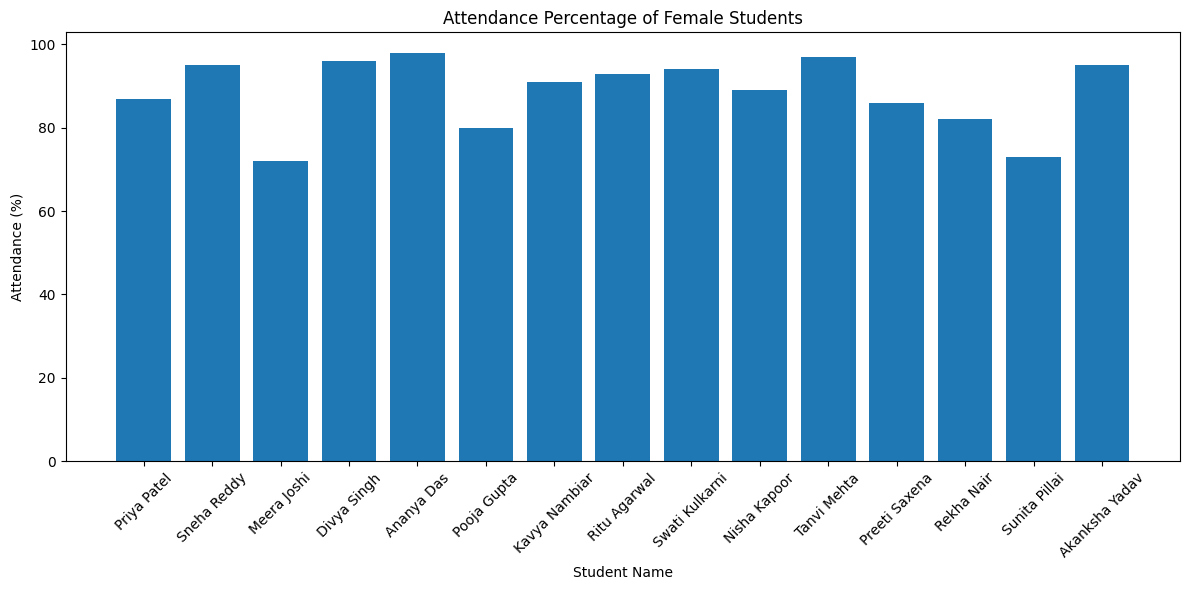

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(result['name'], result['attendance_percentage'])

plt.title('Attendance Percentage of Female Students')
plt.xlabel('Student Name')
plt.ylabel('Attendance (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
def text_to_sql_agent(user_question, conn, client, model, verbose=True):
 print(f" question :{user_question}")
 print("=" * 60)

 if verbose:
  print("\n[STEP 1] Reading database schema...")

  schema_text = get_schema(conn)

  if verbose:
    print("Schema loaded successfully")

In [ ]:
def text_to_sql_agent(user_question, conn, client, model, verbose=True):
 print(f" question :{user_question}")
 print("=" * 60)

 if verbose:
  print("\n[STEP 1] Reading database schema...")

  schema_text = get_schema(conn)

  if verbose:
    print("Schema loaded successfully")

    if verbose:
      print(f"Generating SQL : \n {schema_text}") # Changed from generates_sql to schema_text for debug clarity


    if verbose:
      print("\n[STEP 2] Generating SQL query with Groq LLM...")

    generated_sql = generate_sql(user_question, schema_text, client, model)

    if verbose:
      print("SQL query generated successfully")
      print(f"Generated SQL: {generated_sql}") # Display generated SQL

    if verbose:
      print(f"Executing SQL on the database...")

    result_df, error = execute_sql(generated_sql, conn)

    if error:
      print(f"SQL Execution Error: {error}")
      return None, generated_sql # Return None for result_df on error

    if verbose:
      print(f"\n[STEP 4] QUERY returned {len(result_df)} row(s)")
      print("\nRESULTS:")
      print("-" * 40)
      print(result_df.to_string(index=False))
      print("=" * 40)

    return result_df, generated_sql

# The following lines were incorrectly indented and are now moved outside the function definition
# to demonstrate how to call the function.

# Example usage:
# question_to_ask = "show me all female students"
# result, sql_used = text_to_sql_agent(question_to_ask, conn, client, MODEL)
# if result is not None:
#     print("\nFinal Result DataFrame:")
#     print(result)
# else:
#     print("\nNo results due to an error or empty query.")

In [ ]:
def text_to_sql_agent(user_question, conn, client, model, verbose=True):
  """
  The main AI Agent function that converts natural language questions to SQL queries,
  executes them against a database, and returns the results.

  Args:
    user_question (str): The natural language question from the user.
    conn (sqlite3.Connection): The database connection object.
    client (Groq): The Groq API client.
    model (str): The Groq model to use for SQL generation.
    verbose (bool): If True, prints detailed steps and results.

  Returns:
    A tuple (pandas.DataFrame or None, str):
      - A pandas DataFrame containing the query results if successful, otherwise None.
      - The generated SQL query string.
  """ # Properly closed docstring
  print(f"USER QUESTION: {user_question}")
  print("="*60)
  if verbose:
    print("\n[STEP 1] Reading database schema...")
  schema_text=get_schema(conn)

  if verbose:
    print("Schema loaded successfully!")
  if verbose:
    print("\n[STEP 2] Generating SQL Query with Groq LLM..")

  generated_sql = generate_sql(user_question,schema_text,client,model) # Corrected 'user_function' to 'user_question'

  # The rest of the function logic from the previously corrected cell (bhffGcnH5zWj)
  # would follow here if this was intended to be the complete function.
  # For now, this fixes the syntax and variable name in this specific cell.